In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data.clean_data import basic_clean
from data.load_data import load_raw_data
from eda.summary import data_summary
from data.feature_engineering import prepare_model_data
from export.report_exports import (
    export_report_table,
    create_report_output_dirs,
    save_report_figure,
    set_report_plot_style,
)

NOTEBOOK_NAME = "01_data_audit_and_problem_definition"

report_dirs = create_report_output_dirs(
    project_root=PROJECT_ROOT,
    notebook_name=NOTEBOOK_NAME,
)

OUTPUT_DIR = report_dirs.output_dir
FIGURE_DIR = report_dirs.figure_dir
TABLE_DIR = report_dirs.table_dir

set_report_plot_style()
sns.set_theme(style="whitegrid")

In [2]:
df_raw = load_raw_data()
df = basic_clean(df_raw)

target = "annual_medical_cost"
log_target = "log1p_annual_medical_cost"

df = prepare_model_data(
    df,
    target_col=target,
    add_log=True,
    add_groups=True,
    add_tail_flags=False,
)

print("Shape:", df.shape)
display(df.head())

data_summary_table = data_summary(df)
display(data_summary_table)

Shape: (100000, 58)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,log1p_annual_medical_cost,hospitalizations_grouped,chronic_count_grouped,days_hospitalized_grouped
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,2,0,1,0,0,8.844922,0,1,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,0,1,1,0,7.398548,0,2,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,2,1,0,1,0,8.944030,0,3,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,1,0,0,0,8.543108,0,1,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,1,0,1,0,7.439401,0,2,0


,dtype,missing_count,missing_pct,n_unique
alcohol_freq,str,30083,30.083,3
person_id,int64,0,0.000,100000
annual_medical_cost,float64,0,0.000,91299
log1p_annual_medical_cost,float64,0,0.000,91299
total_claims_paid,float64,0,0.000,56650
annual_premium,float64,0,0.000,55538
avg_claim_amount,float64,0,0.000,53071
monthly_premium,float64,0,0.000,12339
income,float64,0,0.000,2987
ldl,float64,0,0.000,1881


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Tables\tab_01_data_summary.csv


WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/01_data_audit_and_problem_definition/Tables/tab_01_data_summary.csv')

In [3]:
print(df.columns.tolist())

['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure', 'log1p_annual_medical_cost', 'hospitalizations_grouped', 'chronic_count_grouped', 'days_hospitalized_gro

In [4]:
target_summary = df[target].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
        0.995,
    ]
)

print(target_summary)
print("\nSkewness:", df[target].skew())
print("Kurtosis:", df[target].kurt())

target_summary_table = pd.DataFrame({
    "Statistic": [
        "n",
        "Mean",
        "Standard deviation",
        "Minimum",
        "Median",
        "75th percentile",
        "90th percentile",
        "95th percentile",
        "99th percentile",
        "99.5th percentile",
        "Maximum",
        "Skewness",
        "Kurtosis",
    ],
    "Annual medical cost (USD)": [
        df[target].count(),
        df[target].mean(),
        df[target].std(),
        df[target].min(),
        df[target].median(),
        df[target].quantile(0.75),
        df[target].quantile(0.90),
        df[target].quantile(0.95),
        df[target].quantile(0.99),
        df[target].quantile(0.995),
        df[target].max(),
        df[target].skew(),
        df[target].kurt(),
    ],
})

display(target_summary_table)

export_report_table(
    table=target_summary_table,
    table_dir=TABLE_DIR,
    file_stem="tab_01_target_summary",
    caption="Summary statistics for annual medical cost.",
    label="tab:01-target-summary",
)

mean_cost = df[target].mean()
median_cost = df[target].median()
p99_cost = df[target].quantile(0.99)

mean_log_cost = df[log_target].mean()
median_log_cost = df[log_target].median()

count    100000.000000
mean       3009.451907
std        3127.462822
min          55.550000
50%        2082.575000
75%        3707.957500
90%        6227.092000
95%        8570.350500
99%       15293.682200
99.5%     19212.947050
max       65724.900000
Name: annual_medical_cost, dtype: float64

Skewness: 4.030317894409436
Kurtosis: 32.559205950930746


,Statistic,Annual medical cost (USD)
0,n,100000.000000
1,Mean,3009.451907
2,Standard deviation,3127.462822
3,Minimum,55.550000
4,Median,2082.575000
5,75th percentile,3707.957500
6,90th percentile,6227.092000
7,95th percentile,8570.350500
8,99th percentile,15293.682200
9,99.5th percentile,19212.947050


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Tables\tab_01_target_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Tables\tab_01_target_summary.tex


Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Figures\fig_01_annual_cost_distribution.png


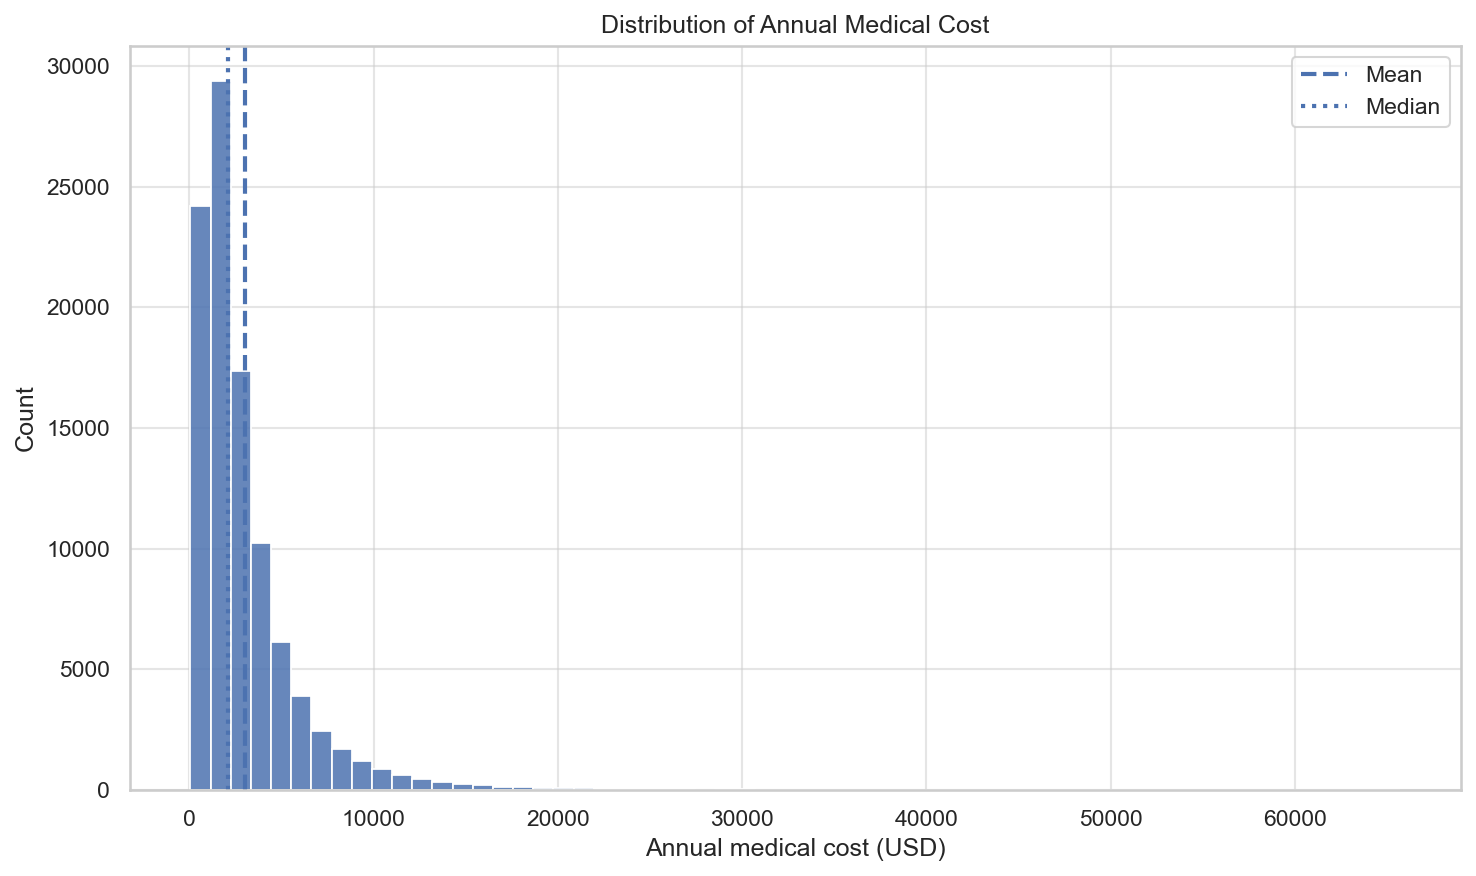

In [5]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.histplot(
    data=df,
    x=target,
    bins=60,
    alpha=0.85,
    edgecolor="white",
    ax=ax,
)

ax.axvline(
    mean_cost,
    linestyle="--",
    linewidth=2,
    label="Mean",
)

ax.axvline(
    median_cost,
    linestyle=":",
    linewidth=2,
    label="Median",
)

ax.set_title("Distribution of Annual Medical Cost")
ax.set_xlabel("Annual medical cost (USD)")
ax.set_ylabel("Count")
ax.legend()

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_01_annual_cost_distribution",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Figures\fig_01_annual_cost_distribution_up_to_p99.png


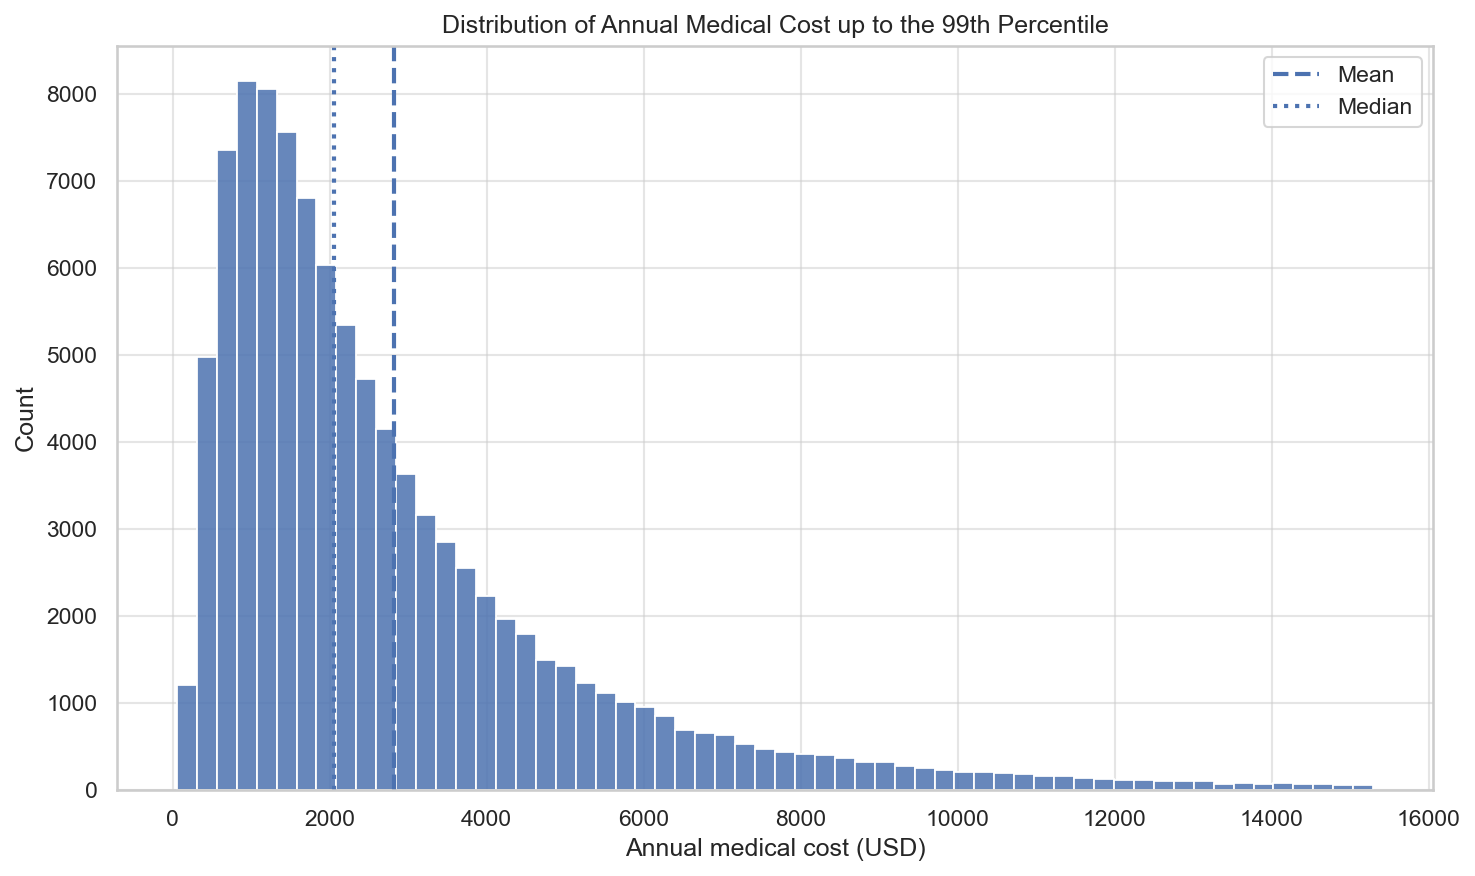

In [6]:
df_body = df[df[target] <= p99_cost]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.histplot(
    data=df_body,
    x=target,
    bins=60,
    alpha=0.85,
    edgecolor="white",
    ax=ax,
)

ax.axvline(
    df_body[target].mean(),
    linestyle="--",
    linewidth=2,
    label="Mean",
)

ax.axvline(
    df_body[target].median(),
    linestyle=":",
    linewidth=2,
    label="Median",
)

ax.set_title("Distribution of Annual Medical Cost up to the 99th Percentile")
ax.set_xlabel("Annual medical cost (USD)")
ax.set_ylabel("Count")
ax.legend()

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_01_annual_cost_distribution_up_to_p99",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Figures\fig_01_log_annual_cost_distribution.png


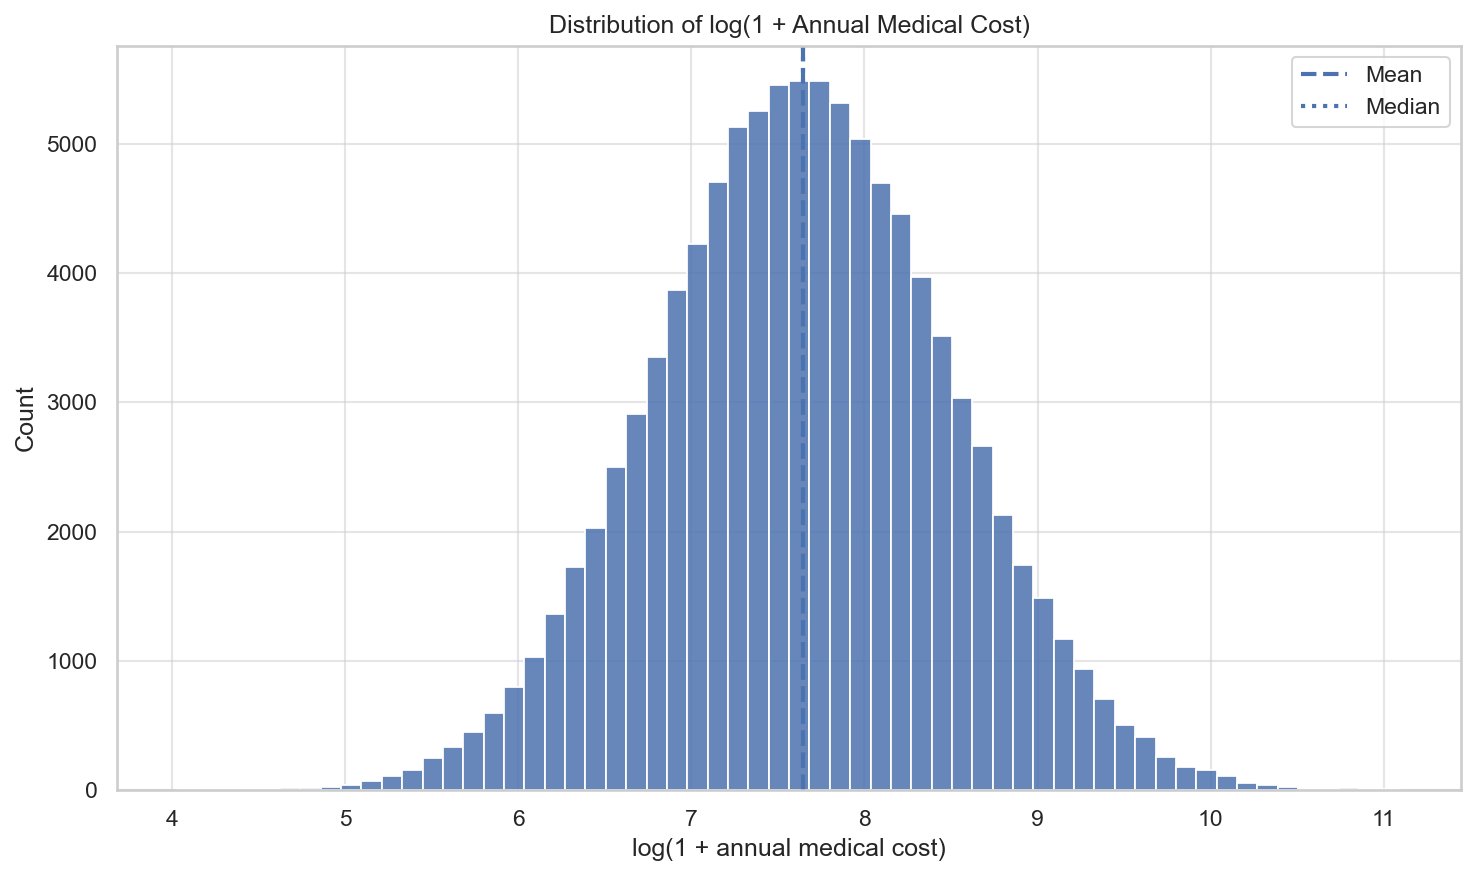

In [7]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.histplot(
    data=df,
    x=log_target,
    bins=60,
    alpha=0.85,
    edgecolor="white",
    ax=ax,
)

ax.axvline(
    mean_log_cost,
    linestyle="--",
    linewidth=2,
    label="Mean",
)

ax.axvline(
    median_log_cost,
    linestyle=":",
    linewidth=2,
    label="Median",
)

ax.set_title("Distribution of log(1 + Annual Medical Cost)")
ax.set_xlabel("log(1 + annual medical cost)")
ax.set_ylabel("Count")
ax.legend()

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_01_log_annual_cost_distribution",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Figures\fig_01_log_annual_cost_boxplot.png


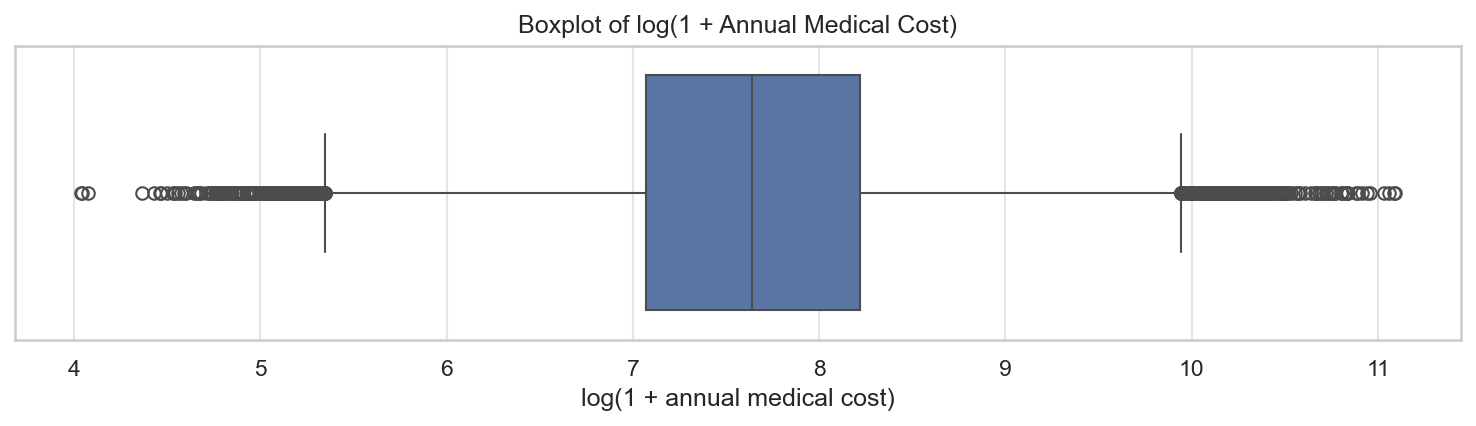

In [8]:
fig, ax = plt.subplots(figsize=(10, 3), dpi=150)

sns.boxplot(
    data=df,
    x=log_target,
    showfliers=True,
    ax=ax,
)

ax.set_title("Boxplot of log(1 + Annual Medical Cost)")
ax.set_xlabel("log(1 + annual medical cost)")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_01_log_annual_cost_boxplot",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Figures\fig_01_log_cost_by_age_smoker.png


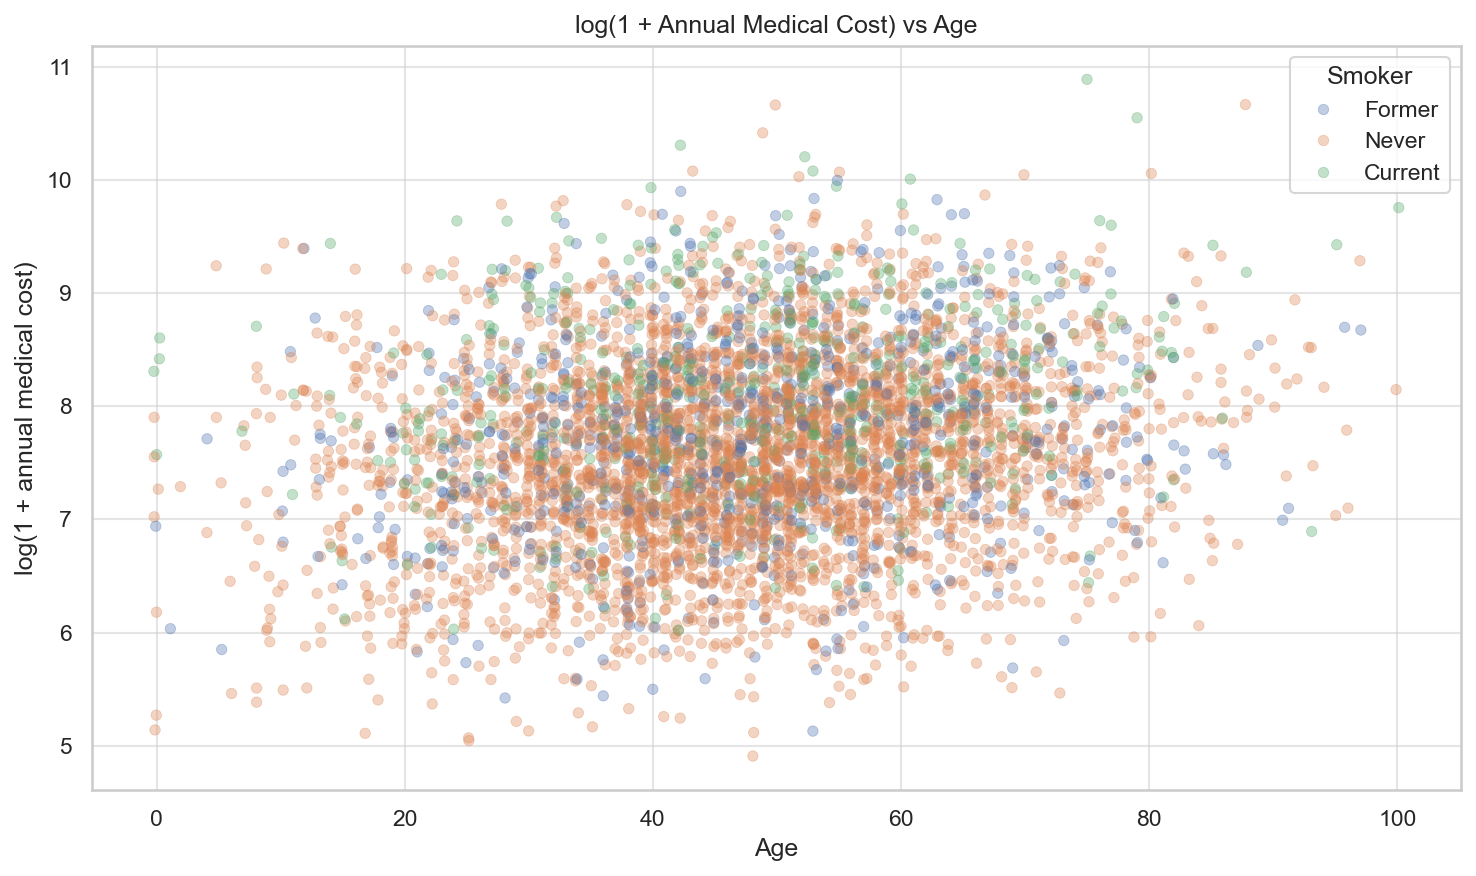

In [9]:
df_plot = df.sample(5000, random_state=42).copy()

rng = np.random.default_rng(42)
df_plot["age_jitter"] = df_plot["age"] + rng.uniform(
    -0.25,
    0.25,
    size=len(df_plot),
)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.scatterplot(
    data=df_plot,
    x="age_jitter",
    y=log_target,
    hue="smoker",
    alpha=0.35,
    s=25,
    edgecolor=None,
    ax=ax,
)

ax.set_title("log(1 + Annual Medical Cost) vs Age")
ax.set_xlabel("Age")
ax.set_ylabel("log(1 + annual medical cost)")
ax.legend(title="Smoker")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_01_log_cost_by_age_smoker",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Figures\fig_01_log_cost_by_raw_hospitalisations.png


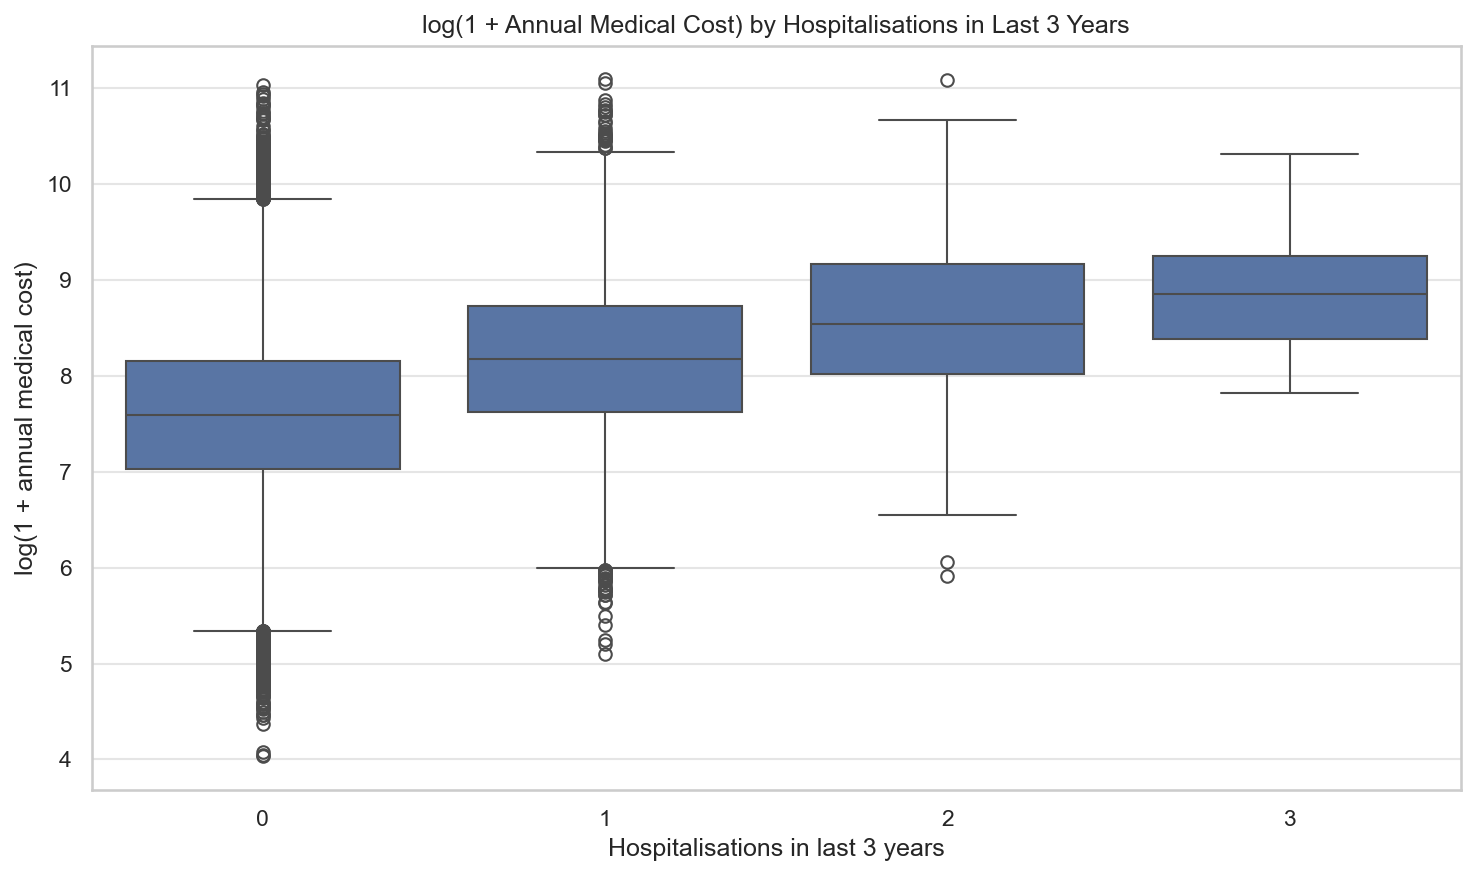

In [10]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.boxplot(
    data=df,
    x="hospitalizations_last_3yrs",
    y=log_target,
    showfliers=True,
    ax=ax,
)

ax.set_title("log(1 + Annual Medical Cost) by Hospitalisations in Last 3 Years")
ax.set_xlabel("Hospitalisations in last 3 years")
ax.set_ylabel("log(1 + annual medical cost)")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_01_log_cost_by_raw_hospitalisations",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Figures\fig_01_log_cost_by_raw_chronic_count.png


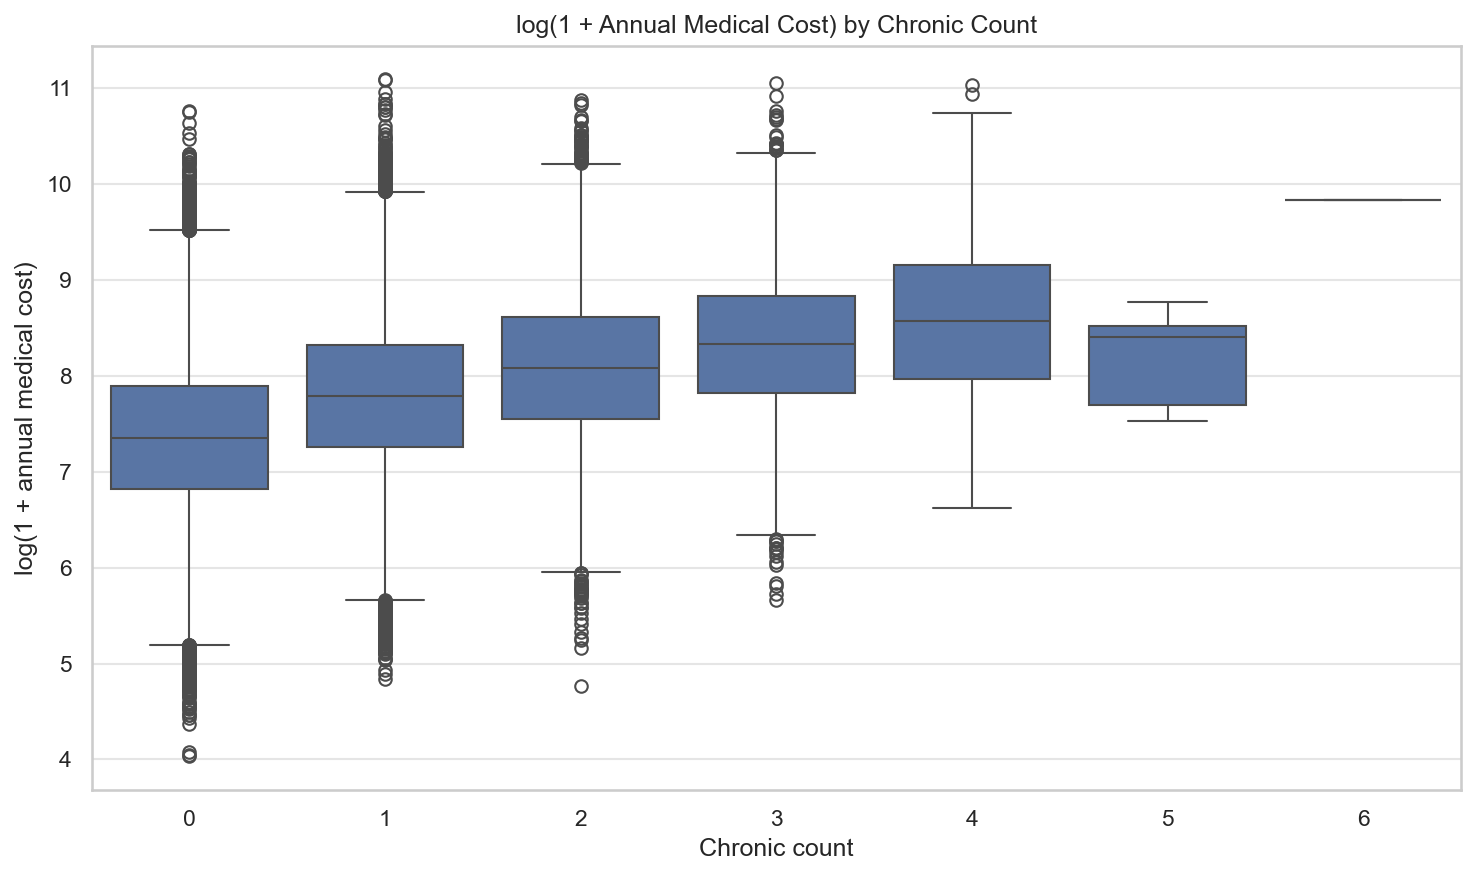

In [11]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.boxplot(
    data=df,
    x="chronic_count",
    y=log_target,
    showfliers=True,
    ax=ax,
)

ax.set_title("log(1 + Annual Medical Cost) by Chronic Count")
ax.set_xlabel("Chronic count")
ax.set_ylabel("log(1 + annual medical cost)")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_01_log_cost_by_raw_chronic_count",
)

plt.show()

In [12]:
print(df["hospitalizations_last_3yrs"].value_counts().sort_index())
print()
print(df["chronic_count"].value_counts().sort_index())

hospitalizations_last_3yrs
0    91031
1     8582
2      379
3        8
Name: count, dtype: int64

chronic_count
0    46532
1    37579
2    13111
3     2452
4      316
5        9
6        1
Name: count, dtype: int64


In [13]:
print(df["hospitalizations_grouped"].value_counts().sort_index())
print()
print(df["chronic_count_grouped"].value_counts().sort_index())

hospitalizations_grouped
0     91031
1      8582
2+      387
Name: count, dtype: int64

chronic_count_grouped
0     46532
1     37579
2     13111
3      2452
4+      326
Name: count, dtype: int64


In [14]:
grouped_hospitalisation_counts = (
    df["hospitalizations_grouped"]
    .value_counts()
    .sort_index()
    .rename_axis("Group")
    .reset_index(name="n")
)

grouped_hospitalisation_counts["Variable"] = "Hospitalisations in last 3 years"

grouped_chronic_counts = (
    df["chronic_count_grouped"]
    .value_counts()
    .sort_index()
    .rename_axis("Group")
    .reset_index(name="n")
)

grouped_chronic_counts["Variable"] = "Chronic disease count"

grouped_health_counts_table = pd.concat(
    [
        grouped_hospitalisation_counts,
        grouped_chronic_counts,
    ],
    ignore_index=True,
)

grouped_health_counts_table = grouped_health_counts_table[
    [
        "Variable",
        "Group",
        "n",
    ]
]

display(grouped_health_counts_table)

export_report_table(
    table=grouped_health_counts_table,
    table_dir=TABLE_DIR,
    file_stem="tab_01_grouped_health_counts",
    caption="Policyholder counts by grouped health-risk variable.",
    label="tab:01-grouped-health-counts",
    float_format="%.0f",
)

,Variable,Group,n
0,Hospitalisations in last 3 years,0,91031
1,Hospitalisations in last 3 years,1,8582
2,Hospitalisations in last 3 years,2+,387
3,Chronic disease count,0,46532
4,Chronic disease count,1,37579
5,Chronic disease count,2,13111
6,Chronic disease count,3,2452
7,Chronic disease count,4+,326


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Tables\tab_01_grouped_health_counts.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Tables\tab_01_grouped_health_counts.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/01_data_audit_and_problem_definition/Tables/tab_01_grouped_health_counts.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/01_data_audit_and_problem_definition/Tables/tab_01_grouped_health_counts.tex')}

In [15]:
hospital_grouped_summary = (
    df.groupby("hospitalizations_grouped", observed=True)["annual_medical_cost"]
    .agg(
        n="size",
        mean="mean",
        median="median",
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .round(2)
)

hospital_grouped_summary

,n,mean,median,p90,p95,p99
hospitalizations_grouped,,,,,,
0,91031,2810.44,1977.55,5794.89,7889.32,13910.33
1,8582,4919.63,3539.12,9974.18,13216.47,23232.70
2+,387,7461.11,5108.38,16076.31,20864.75,30406.74


In [16]:
hospital_grouped_summary_export = (
    hospital_grouped_summary
    .reset_index()
    .rename(columns={
        "hospitalizations_grouped": "Hospitalisations in last 3 years",
        "n": "n",
        "mean": "Mean cost (USD)",
        "median": "Median cost (USD)",
        "p90": "p90 cost (USD)",
        "p95": "p95 cost (USD)",
        "p99": "p99 cost (USD)",
    })
)

display(hospital_grouped_summary_export)

export_report_table(
    table=hospital_grouped_summary_export,
    table_dir=TABLE_DIR,
    file_stem="tab_01_hospitalisation_grouped_summary",
    caption="Annual medical cost by grouped hospitalisation history.",
    label="tab:01-hospitalisation-grouped-summary",
)

,Hospitalisations in last 3 years,n,Mean cost (USD),Median cost (USD),p90 cost (USD),p95 cost (USD),p99 cost (USD)
0,0,91031,2810.44,1977.55,5794.89,7889.32,13910.33
1,1,8582,4919.63,3539.12,9974.18,13216.47,23232.70
2,2+,387,7461.11,5108.38,16076.31,20864.75,30406.74


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Tables\tab_01_hospitalisation_grouped_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Tables\tab_01_hospitalisation_grouped_summary.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/01_data_audit_and_problem_definition/Tables/tab_01_hospitalisation_grouped_summary.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/01_data_audit_and_problem_definition/Tables/tab_01_hospitalisation_grouped_summary.tex')}

In [17]:
chronic_grouped_summary = (
    df.groupby("chronic_count_grouped", observed=True)["annual_medical_cost"]
    .agg(
        n="size",
        mean="mean",
        median="median",
        p90=lambda x: x.quantile(0.90),
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .round(2)
)

chronic_grouped_summary

,n,mean,median,p90,p95,p99
chronic_count_grouped,,,,,,
0,46532,2176.33,1558.97,4396.05,5949.58,10487.04
1,37579,3332.01,2415.40,6711.20,9023.71,15586.62
2,13111,4438.19,3249.83,8993.14,12001.39,20854.28
3,2452,5671.43,4137.85,11207.64,15269.95,26076.46
4+,326,7260.65,5260.05,15120.21,19244.68,30407.02


In [18]:
chronic_grouped_summary_export = (
    chronic_grouped_summary
    .reset_index()
    .rename(columns={
        "chronic_count_grouped": "Chronic disease count group",
        "n": "n",
        "mean": "Mean cost (USD)",
        "median": "Median cost (USD)",
        "p90": "p90 cost (USD)",
        "p95": "p95 cost (USD)",
        "p99": "p99 cost (USD)",
    })
)

display(chronic_grouped_summary_export)

export_report_table(
    table=chronic_grouped_summary_export,
    table_dir=TABLE_DIR,
    file_stem="tab_01_chronic_count_grouped_summary",
    caption="Annual medical cost by grouped chronic disease count.",
    label="tab:01-chronic-count-grouped-summary",
)

,Chronic disease count group,n,Mean cost (USD),Median cost (USD),p90 cost (USD),p95 cost (USD),p99 cost (USD)
0,0,46532,2176.33,1558.97,4396.05,5949.58,10487.04
1,1,37579,3332.01,2415.40,6711.20,9023.71,15586.62
2,2,13111,4438.19,3249.83,8993.14,12001.39,20854.28
3,3,2452,5671.43,4137.85,11207.64,15269.95,26076.46
4,4+,326,7260.65,5260.05,15120.21,19244.68,30407.02


Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Tables\tab_01_chronic_count_grouped_summary.csv
Saved table: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Tables\tab_01_chronic_count_grouped_summary.tex


{'csv': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/01_data_audit_and_problem_definition/Tables/tab_01_chronic_count_grouped_summary.csv'),
 'tex': WindowsPath('C:/Users/maxfa/OneDrive/Documents/University/Part-Time/Project/Medical Insurance/Medical Insurance/Outputs/01_data_audit_and_problem_definition/Tables/tab_01_chronic_count_grouped_summary.tex')}

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Figures\fig_01_log_cost_by_grouped_hospitalisations.png


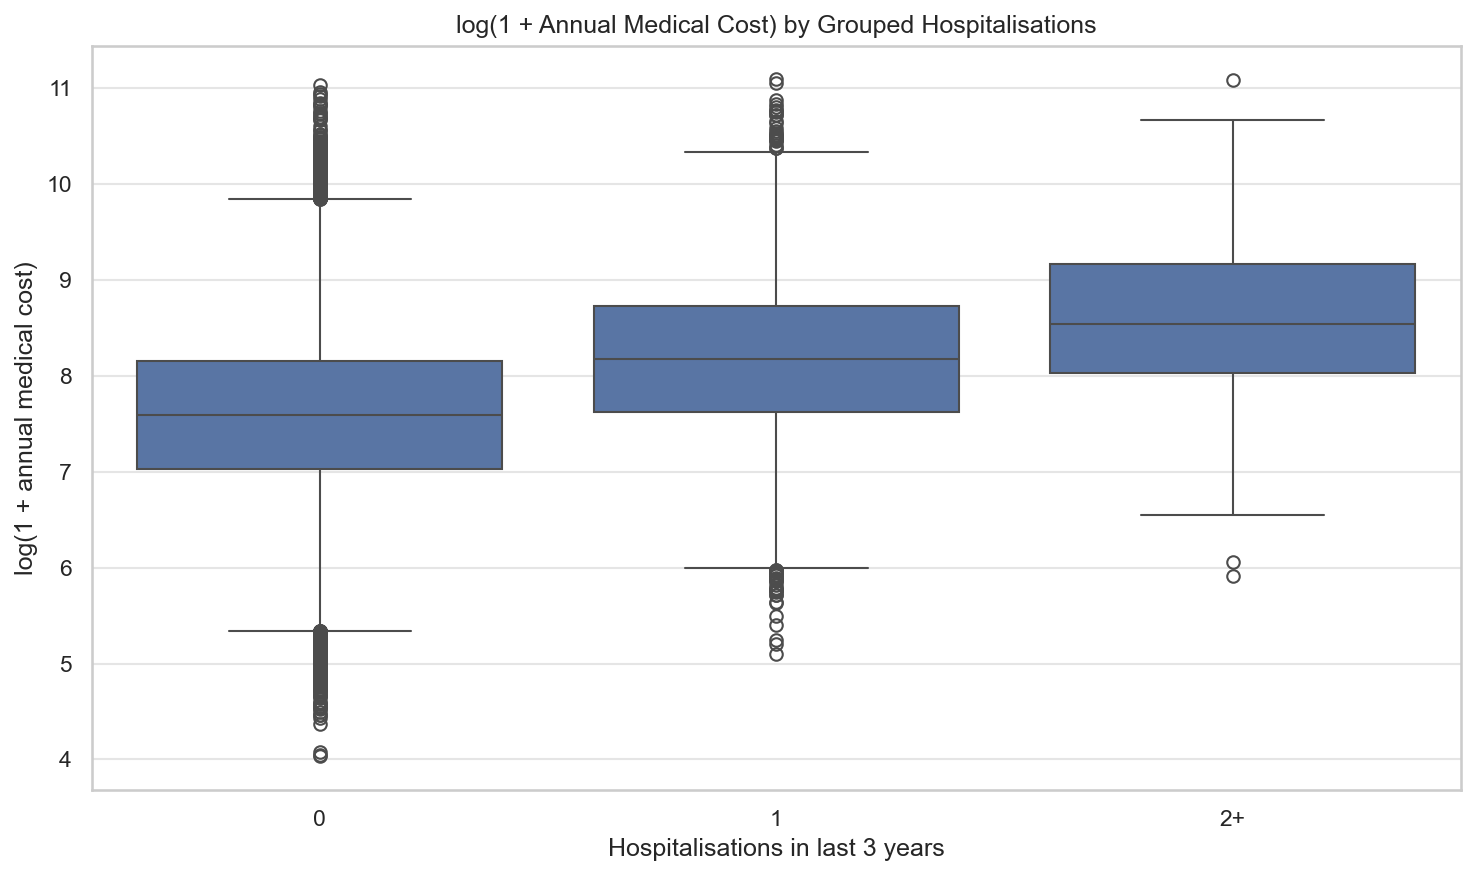

In [19]:
hospital_order = ["0", "1", "2+"]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.boxplot(
    data=df,
    x="hospitalizations_grouped",
    y=log_target,
    order=hospital_order,
    showfliers=True,
    ax=ax,
)

ax.set_title("log(1 + Annual Medical Cost) by Grouped Hospitalisations")
ax.set_xlabel("Hospitalisations in last 3 years")
ax.set_ylabel("log(1 + annual medical cost)")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_01_log_cost_by_grouped_hospitalisations",
)

plt.show()

Saved figure: C:\Users\maxfa\OneDrive\Documents\University\Part-Time\Project\Medical Insurance\Medical Insurance\Outputs\01_data_audit_and_problem_definition\Figures\fig_01_log_cost_by_grouped_chronic_count.png


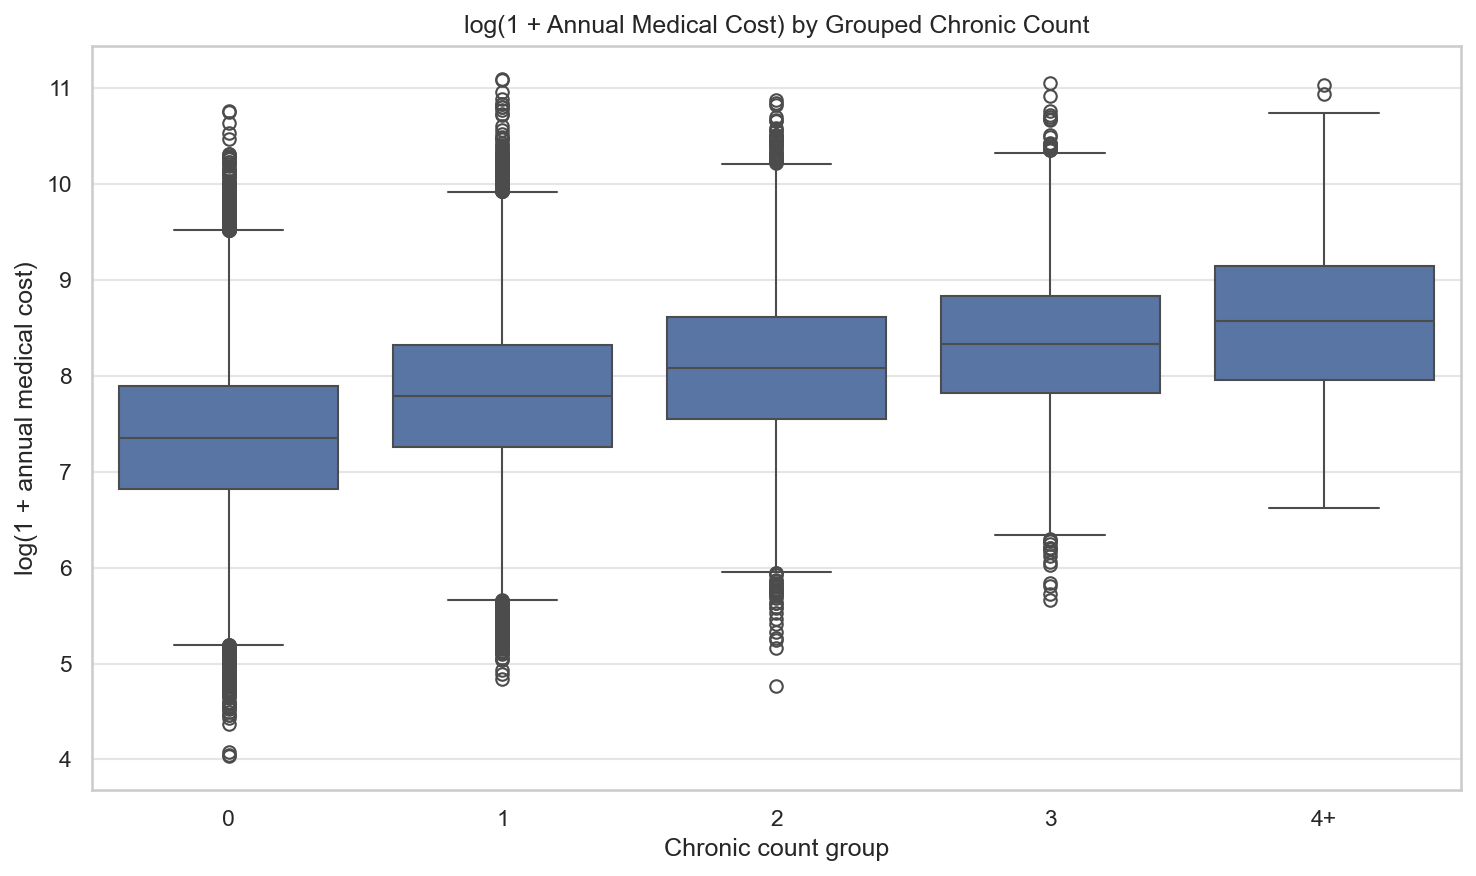

In [20]:
chronic_order = ["0", "1", "2", "3", "4+"]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

sns.boxplot(
    data=df,
    x="chronic_count_grouped",
    y=log_target,
    order=chronic_order,
    showfliers=True,
    ax=ax,
)

ax.set_title("log(1 + Annual Medical Cost) by Grouped Chronic Count")
ax.set_xlabel("Chronic count group")
ax.set_ylabel("log(1 + annual medical cost)")

fig.tight_layout()

save_report_figure(
    fig=fig,
    figure_dir=FIGURE_DIR,
    file_stem="fig_01_log_cost_by_grouped_chronic_count",
)

plt.show()